In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

# Visualizing COVID Vaccination Outcomes
We explore honest and deceptive graphics drawn from the same dataset to stress how design choices can shape perception.

https://openintro.org/data/csv/simpsons_paradox_covid.csv

In [13]:
df = pd.read_csv('data/simpsons_paradox/simpsons_paradox_covid.csv')

In [15]:
df.head()

,age_group,vaccine_status,outcome
0,under 50,vaccinated,death
1,under 50,vaccinated,death
2,under 50,vaccinated,death
3,under 50,vaccinated,death
4,under 50,vaccinated,death


In [16]:
df.groupby(['age_group','vaccine_status','outcome']).size().unstack(fill_value=0)

outcome                   death  survived
age_group vaccine_status                 
50 +      unvaccinated      205      3235
          vaccinated        460     26847
under 50  unvaccinated       48    147564
          vaccinated         21     89786

In [18]:
from matplotlib.path import Path
from matplotlib import markers as mmarkers
from matplotlib.transforms import Affine2D
from matplotlib.lines import Line2D

palette = {'survived': '#2a9d8f', 'death': '#e63946'}
background_color = '#f7f4ea'

def create_person_marker():
    head = Path.unit_circle()
    head = Affine2D().scale(0.35).translate(0.0, 0.9).transform_path(head)
    body_vertices = [
        (-0.55, 0.6),
        (-0.25, -0.6),
        (-0.4, -0.6),
        (-0.4, -1.6),
        (-0.15, -1.6),
        (-0.15, -0.9),
        (0.15, -0.9),
        (0.15, -1.6),
        (0.4, -1.6),
        (0.4, -0.6),
        (0.25, -0.6),
        (0.55, 0.6),
        (-0.55, 0.6),
        (-0.55, 0.6)
    ]
    body_codes = [Path.MOVETO] + [Path.LINETO] * (len(body_vertices) - 2) + [Path.CLOSEPOLY]
    body = Path(body_vertices, body_codes)
    return mmarkers.MarkerStyle(Path.make_compound_path(head, body))

def build_icon_grid(counts, total_icons=100, n_cols=10):
    proportional = (counts / counts.sum() * total_icons).round().astype(int)
    diff = total_icons - proportional.sum()
    if diff != 0:
        adjust_target = proportional.idxmax() if diff > 0 else proportional[proportional > 0].idxmax()
        proportional.loc[adjust_target] += diff
    rows = []
    running = 0
    for outcome, count in proportional.items():
        for _ in range(count):
            col = running % n_cols
            row = running // n_cols
            rows.append({'col': col, 'row': row, 'outcome': outcome})
            running += 1
    return pd.DataFrame(rows)

In [21]:
summary = (
    df.groupby(['age_group', 'vaccine_status', 'outcome'])
    .size()
    .rename('count')
    .reset_index()
 )
summary['group_total'] = summary.groupby(['age_group', 'vaccine_status'])['count'].transform('sum')
summary['share'] = summary['count'] / summary['group_total']
summary.head()

,age_group,vaccine_status,outcome,count,group_total,share
0,50 +,unvaccinated,death,205,3440,0.059593
1,50 +,unvaccinated,survived,3235,3440,0.940407
2,50 +,vaccinated,death,460,27307,0.016845
3,50 +,vaccinated,survived,26847,27307,0.983155
4,under 50,unvaccinated,death,48,147612,0.000325


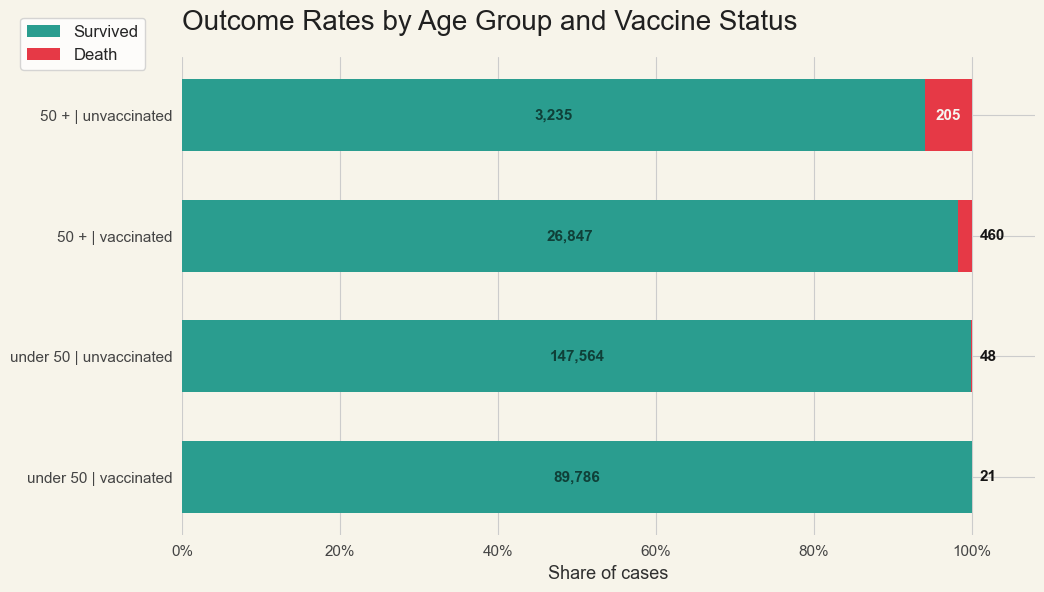

In [51]:
fig, ax = plt.subplots(figsize=(11, 6.2))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
ordered = summary.copy()
ordered['age_group'] = pd.Categorical(ordered['age_group'], ['under 50', '50 +'])
ordered['vaccine_status'] = pd.Categorical(ordered['vaccine_status'], ['vaccinated', 'unvaccinated'])
ordered = ordered.sort_values(['age_group', 'vaccine_status'])
ordered['label'] = ordered['age_group'].astype(str) + ' | ' + ordered['vaccine_status'].astype(str)
labels = ordered['label'].unique()
outcome_order = ['survived', 'death']
pivot = (
    ordered.pivot_table(
        index='label',
        columns='outcome',
        values='share',
        fill_value=0
    )
    .reindex(labels)
    [outcome_order]
 )
counts = (
    ordered.pivot_table(
        index='label',
        columns='outcome',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(labels)
    [outcome_order]
 )
bottom = np.zeros(len(labels))
for outcome in outcome_order:
    ax.barh(
        labels,
        pivot[outcome],
        left=bottom,
        color=palette[outcome],
        edgecolor='none',
        label=outcome.title(),
        height=0.6
    )
    bottom += pivot[outcome].values
ax.set_xlabel('Share of cases', fontsize=13, color='#303030')
ax.set_ylabel('')
ax.set_xlim(0, 1.08)
ax.xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax.tick_params(colors='#444444', labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
legend = ax.legend(frameon=True, loc='upper left', fontsize=12, bbox_to_anchor=(-0.2, 1.1))
# legend.get_frame().set_facecolor('#efe8da')
# legend.get_frame().set_edgecolor('#d8cfbf')
# legend.get_frame().set_linewidth(0.8)
# legend.get_frame().set_boxstyle('round,pad=0.4,rounding_size=8')
ax.set_title('Outcome Rates by Age Group and Vaccine Status', loc='left', fontsize=20, color='#202020', pad=20)
# ax.text(0, 1.07, 'Survival dominates every group yet deaths climb with age and missing vaccines.', transform=ax.transAxes, fontsize=12, color='#525252')
for i, label in enumerate(labels):
    start = 0
    for outcome in outcome_order:
        share = pivot.loc[label, outcome]
        count_val = counts.loc[label, outcome]
        if share == 0 or count_val == 0:
            continue
        text = f"{int(count_val):,}"
        center = start + share / 2
        if outcome == 'death' and share < 0.03:
            ax.text(
                min(start + share + 0.01, 1.05),
                label,
                text,
                va='center',
                ha='left',
                fontsize=11,
                # color='#b12c38',
                color="#161515",
                fontweight='semibold'
            )
        else:
            ax.text(
                center,
                label,
                text,
                va='center',
                ha='center',
                fontsize=11,
                color='#0f4038' if outcome == 'survived' else '#f7f6f0',
                fontweight='semibold'
            )
        start += share
plt.savefig('imgs/outcome_rates_by_group.png', dpi=300, bbox_inches='tight', facecolor=background_color)
plt.show()

## Simpson's Paradox Overview
Aggregating the age groups flips the story: the vaccinated group now shows a larger death share because the population skews older.

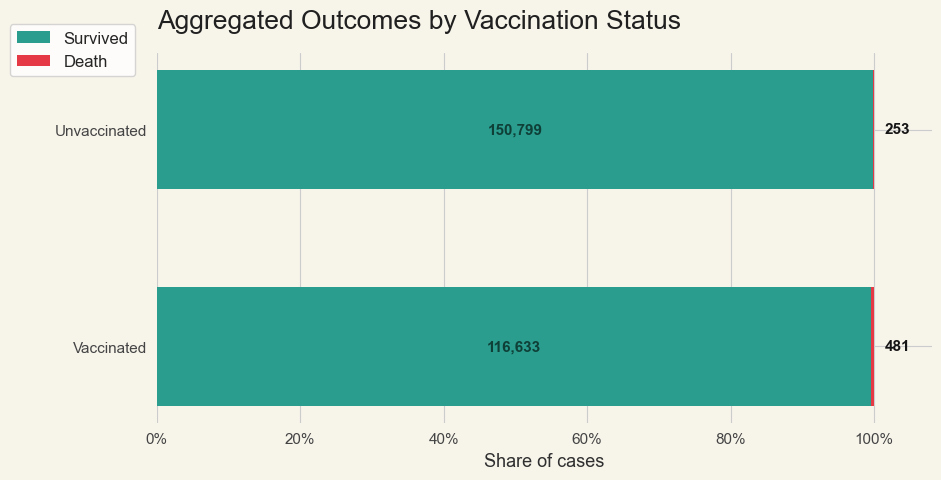

In [61]:
agg = (
    summary.groupby(['vaccine_status', 'outcome'], as_index=False)['count']
    .sum()
 )
status_order_simple = ['vaccinated', 'unvaccinated']
agg['vaccine_status'] = pd.Categorical(agg['vaccine_status'], status_order_simple)
agg = agg.sort_values(['vaccine_status', 'outcome'])
agg['share'] = agg.groupby('vaccine_status')['count'].transform(lambda x: x / x.sum())
labels_simple = [status.title() for status in status_order_simple]
pivot_simple = (
    agg.pivot_table(
        index='vaccine_status',
        columns='outcome',
        values='share',
        fill_value=0
    )
    .reindex(status_order_simple)
    [outcome_order]
 )
counts_simple = (
    agg.pivot_table(
        index='vaccine_status',
        columns='outcome',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(status_order_simple)
    [outcome_order]
 )
fig, ax = plt.subplots(figsize=(10, 4.8))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
bottom = np.zeros(len(labels_simple))
for outcome in outcome_order:
    ax.barh(
        labels_simple,
        pivot_simple[outcome],
        left=bottom,
        color=palette[outcome],
        edgecolor='none',
        height=0.55,
        label=outcome.title()
    )
    bottom += pivot_simple[outcome].values
ax.set_xlabel('Share of cases', fontsize=13, color='#303030')
ax.set_ylabel('')
ax.set_xlim(0, 1.08)
ax.xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax.tick_params(colors='#444444', labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
legend = ax.legend(frameon=True, loc='upper left', fontsize=12, bbox_to_anchor=(-0.2, 1.1))
ax.set_title("Aggregated Outcomes by Vaccination Status", loc='left', fontsize=19, color='#202020', pad=18)
# ax.text(0.02, 1.04, 'Aggregating ages reverses the death rates because vaccinated residents skew older.', transform=ax.transAxes, fontsize=12, color='#525252')
for idx, label in enumerate(labels_simple):
    start = 0
    for outcome in outcome_order:
        share = pivot_simple.iloc[idx][outcome]
        count_val = counts_simple.iloc[idx][outcome]
        if share == 0 or count_val == 0:
            continue
        text = f"{int(count_val):,}"
        center = start + share / 2
        if outcome == 'death' and share < 0.03:
            ax.text(
                min(start + share + 0.015, 1.05),
                label,
                text,
                va='center',
                ha='left',
                fontsize=11,
                color='#161515',
                fontweight='semibold'
            )
        else:
            ax.text(
                center,
                label,
                text,
                va='center',
                ha='center',
                fontsize=11,
                color='#0f4038' if outcome == 'survived' else '#f7f6f0',
                fontweight='semibold'
            )
        start += share
death_gap = pivot_simple.loc['vaccinated', 'death'] - pivot_simple.loc['unvaccinated', 'death']
# ax.annotate(
#     f"Vaccinated death share higher by {death_gap:.2%}",
#     xy=(pivot_simple.loc['vaccinated', 'death'] + 0.02, labels_simple[0]),
#     xytext=(0.52, 0.12),
#     textcoords='axes fraction',
#     arrowprops=dict(arrowstyle='->', color='#b12c38', linewidth=1.4),
#     fontsize=12,
#     color='#b12c38'
#  )
plt.savefig('imgs/simpsons_paradox_overview.png', dpi=300, bbox_inches='tight', facecolor=background_color)
plt.show()

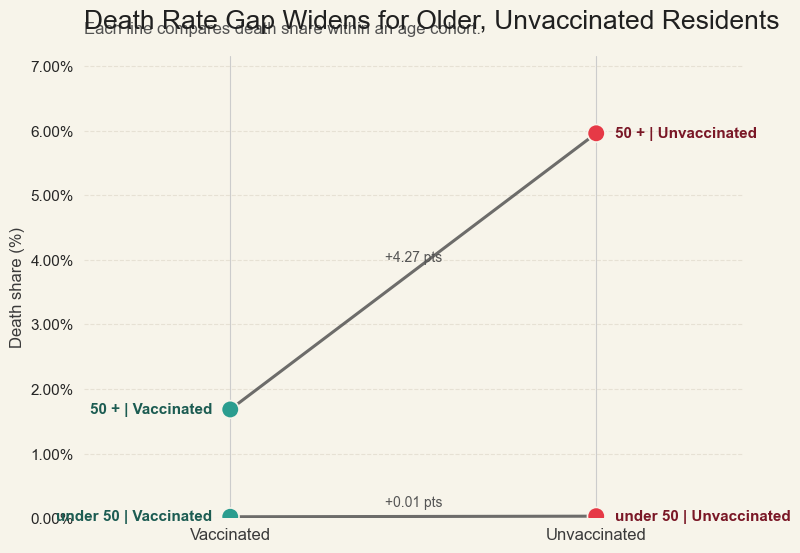

In [ ]:
slope_data = (
    summary[summary['outcome'] == 'death'][['age_group', 'vaccine_status', 'share']]
    .assign(death_rate=lambda df_: df_['share'] * 100)
    .drop(columns='share')
 )
order_age = ['under 50', '50 +']
slope_data['age_group'] = pd.Categorical(slope_data['age_group'], order_age)
slope_data = slope_data.sort_values(['age_group', 'vaccine_status'])
fig, ax = plt.subplots(figsize=(8.5, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
x_positions = {'vaccinated': 0, 'unvaccinated': 1}
for age, group in slope_data.groupby('age_group'):
    xs = [x_positions['vaccinated'], x_positions['unvaccinated']]
    ys = group.set_index('vaccine_status').loc[['vaccinated', 'unvaccinated'], 'death_rate']
    ax.plot(xs, ys, color='#4a4a4a', linewidth=2.2, alpha=0.8)
    ax.scatter(xs, ys, s=[160, 160], c=['#2a9d8f', '#e63946'], edgecolors='#f7f4ea', linewidths=1.2, zorder=3)
    ax.text(-0.05, ys.iloc[0], f"{age} | Vaccinated", ha='right', va='center', fontsize=11, color='#1c5c52', fontweight='semibold')
    ax.text(1.05, ys.iloc[1], f"{age} | Unvaccinated", ha='left', va='center', fontsize=11, color='#7a1726', fontweight='semibold')
    delta = ys.iloc[1] - ys.iloc[0]
    ax.annotate(
        f"+{delta:.2f} pts",
        xy=(0.5, ys.mean()),
        xytext=(0.5, ys.mean() + 0.15),
        textcoords='data',
        ha='center',
        fontsize=10,
        color='#555555'
    )
ax.set_xlim(-0.4, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Vaccinated', 'Unvaccinated'], fontsize=12, color='#3a3a3a')
ax.set_ylabel('Death share (%)', fontsize=12, color='#3a3a3a')
ax.set_ylim(0, slope_data['death_rate'].max() * 1.2)
ax.yaxis.set_major_formatter(lambda y, _: f'{y:.2f}%')
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', color='#e0dacc', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title('Death Rate Gap Widens for Older, Unvaccinated Residents', fontsize=19, color='#202020', loc='left', pad=20)
ax.text(0, 1.03, 'Each line compares death share within an age cohort.', transform=ax.transAxes, fontsize=12, color='#525252')
plt.savefig('imgs/death_rate_slope.png', dpi=300, bbox_inches='tight', facecolor=background_color)
plt.show()

In [53]:
df

,age_group,vaccine_status,outcome
0,under 50,vaccinated,death
1,under 50,vaccinated,death
2,under 50,vaccinated,death
3,under 50,vaccinated,death
4,under 50,vaccinated,death
...,...,...,...
268161,50 +,unvaccinated,survived
268162,50 +,unvaccinated,survived
268163,50 +,unvaccinated,survived
268164,50 +,unvaccinated,survived


## Misleading View
The next chart exaggerates tiny differences by truncating the vertical axis.

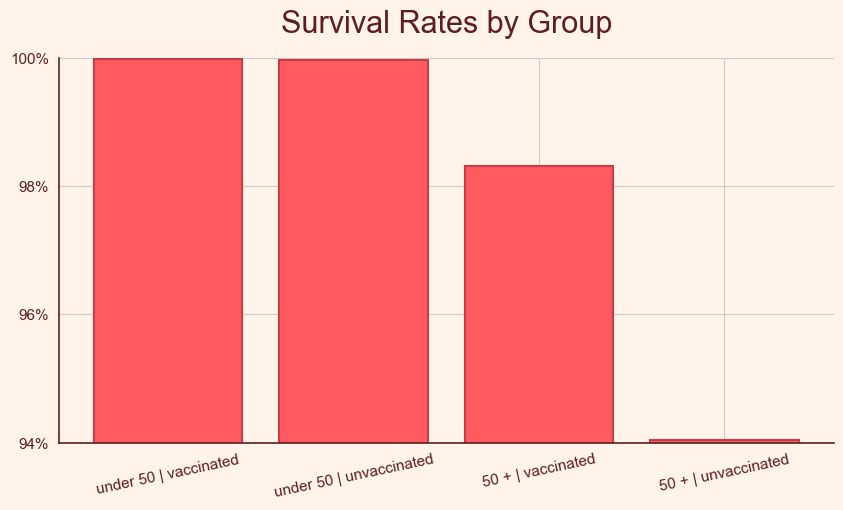

In [56]:
deceptive_bg = '#fff3ea'
highlight = '#ff5a5f'
survival_rates = pivot['survived'].reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(deceptive_bg)
ax.set_facecolor(deceptive_bg)
bars = ax.bar(
    survival_rates['label'],
    survival_rates['survived'],
    color=highlight,
    edgecolor='#c63d48',
    linewidth=1.5
)
ax.set_ylim(0.94, 1.0)
ax.set_yticks(np.linspace(0.94, 1.0, 4))
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax.tick_params(axis='y', colors='#5c1e20', labelsize=11)
ax.tick_params(axis='x', colors='#5c1e20', rotation=12, labelsize=11)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#5c1e20')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_color('#5c1e20')
ax.spines['bottom'].set_linewidth(1.2)
ax.set_title('Survival Rates by Group', fontsize=22, color='#5c1e20', pad=18)
# ax.text(0.02, 0.98, 'Zoomed axis exaggerates small gaps', transform=ax.transAxes, fontsize=12, color='#7a2c2d', va='top')
plt.savefig('imgs/deceptive_survival_zoom.png', dpi=300, bbox_inches='tight', facecolor=deceptive_bg)
plt.show()

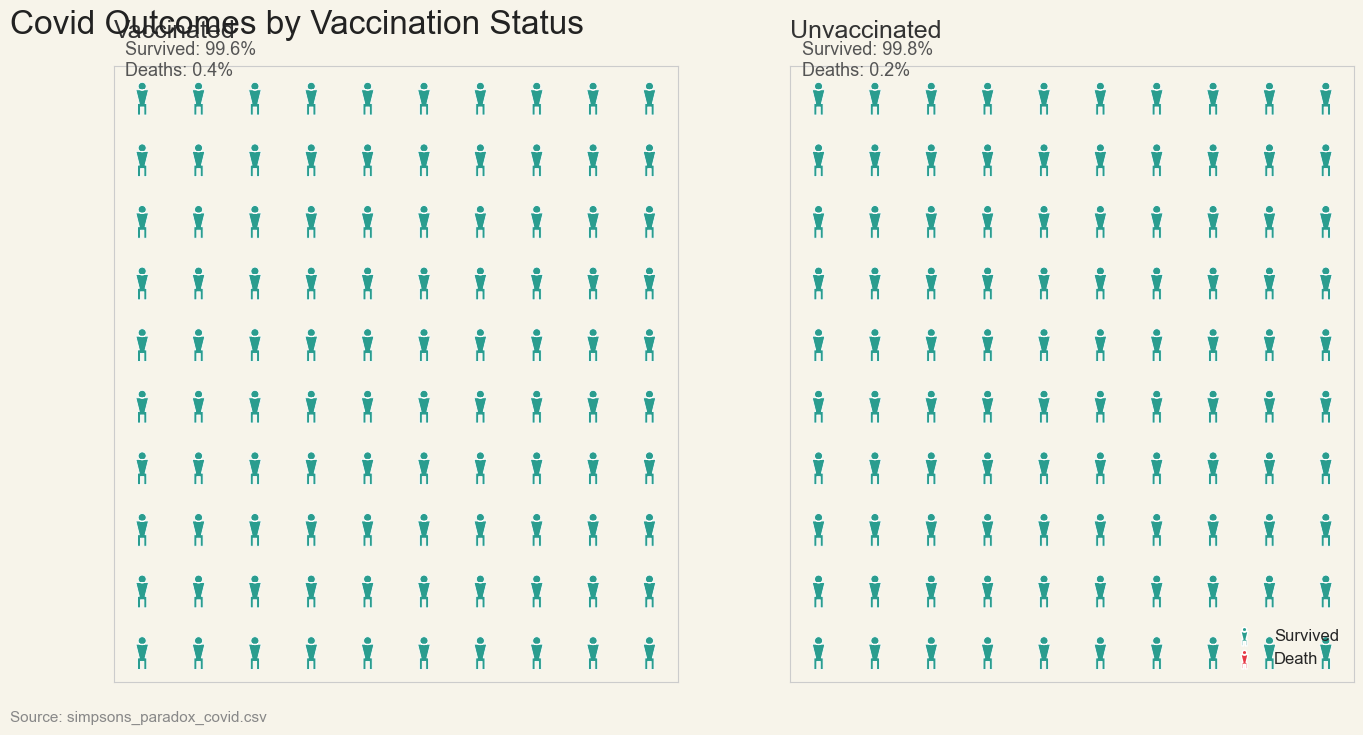

In [35]:
person_marker = create_person_marker()
status_order = ['vaccinated', 'unvaccinated']
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(background_color)
for ax in axes:
    ax.set_facecolor(background_color)
for status, ax in zip(status_order, axes):
    subset = df[df['vaccine_status'] == status]
    counts = subset['outcome'].value_counts().reindex(['survived', 'death']).fillna(0).astype(int)
    icon_grid = build_icon_grid(counts)
    ax.scatter(
        icon_grid['col'],
        icon_grid['row'],
        marker=person_marker,
        s=700,
        c=icon_grid['outcome'].map(palette),
        linewidth=0.6,
        edgecolors='#fefefe'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)
    ax.invert_yaxis()
    ax.set_title(status.title(), loc='left', fontsize=18, color='#333333', pad=20)
    total = counts.sum()
    death_rate = counts['death'] / total if total else 0
    survival_rate = counts['survived'] / total if total else 0
    ax.text(
        -0.3,
        -0.9,
        f"Survived: {survival_rate:.1%}\nDeaths: {death_rate:.1%}",
        ha='left',
        va='top',
        fontsize=13,
        color='#555555'
    )
legend_elements = [
    Line2D([0], [0], marker=person_marker, color='w', markerfacecolor=palette['survived'], markersize=15, linewidth=0),
    Line2D([0], [0], marker=person_marker, color='w', markerfacecolor=palette['death'], markersize=15, linewidth=0)
 ]
axes[1].legend(
    legend_elements,
    ['Survived', 'Death'],
    frameon=False,
    loc='lower right',
    fontsize=12
 )
fig.suptitle('Covid Outcomes by Vaccination Status', fontsize=24, color='#222222', x=0.06, ha='left', y=0.95)
# fig.text(0.06, 0.89, 'Each icon represents roughly 1% of patients within the vaccination group.', fontsize=14, color='#555555')
fig.text(0.06, 0.06, 'Source: simpsons_paradox_covid.csv', fontsize=11, color='#888888')
plt.savefig('imgs/vaccine_outcome_pictogram.png', dpi=300, bbox_inches='tight', facecolor=background_color)
plt.show()